In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Display settings for clean notebook outputs.
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 80)

DATA_PATH = "../../Data/raw/ecommerce_customer_churn_dataset.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 50,000 rows x 25 columns


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,9.0,94.72,34.0,46.40,2.0,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,19.5,82.45,71.0,57.96,9.2,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,9.1,165.52,11.0,12.24,11.5,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,15.0,147.33,47.0,44.10,5.4,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,32.5,141.30,73.0,25.20,5.5,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [2]:
# High-level schema and data quality snapshot.
data_overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=False)
}).sort_values(["dtype", "missing_count"], ascending=[True, False])

data_overview

,dtype,missing_count,missing_pct,n_unique
Social_Media_Engagement_Score,float64,6000,12.00,973
Credit_Balance,float64,5500,11.00,5235
Mobile_App_Usage,float64,5000,10.00,541
Returns_Rate,float64,4491,8.98,395
Wishlist_Items,float64,4000,8.00,26
Discount_Usage_Rate,float64,3500,7.00,1728
Product_Reviews_Written,float64,3500,7.00,19
Session_Duration_Avg,float64,3399,6.80,659
Pages_Per_Session,float64,3000,6.00,225
Days_Since_Last_Purchase,float64,3000,6.00,236


### Categorical Features Analysis

In [3]:
cat_cols = df.select_dtypes(include=["object", "string"]).columns

cat_summary = pd.DataFrame({
    "n_unique": df[cat_cols].nunique(dropna=False),
    "missing_count": df[cat_cols].isna().sum(),
    "missing_pct": (df[cat_cols].isna().mean() * 100).round(2),
    "mode": [df[col].mode(dropna=True).iloc[0] if not df[col].mode(dropna=True).empty else np.nan for col in cat_cols]
}).sort_values("n_unique", ascending=False)

cat_summary

,n_unique,missing_count,missing_pct,mode
City,40,0,0.0,Houston
Country,8,0,0.0,USA
Signup_Quarter,4,0,0.0,Q3
Gender,3,0,0.0,Female


In [4]:
def show_top_categories(dataframe, columns, top_n=10):
    """Display top category frequencies for each categorical feature."""
    for col in columns:
        counts = dataframe[col].value_counts(dropna=False).head(top_n)
        summary = counts.rename("count").reset_index().rename(columns={"index": col})
        summary["pct"] = (summary["count"] / len(dataframe) * 100).round(2)
        print(f"\n{col} | unique values: {dataframe[col].nunique(dropna=False)}")
        display(summary)

show_top_categories(df, cat_cols, top_n=10)


Gender | unique values: 3


,Gender,count,pct
0,Female,25116,50.23
1,Male,23947,47.89
2,Other,937,1.87



Country | unique values: 8


,Country,count,pct
0,USA,17384,34.77
1,UK,7534,15.07
2,Canada,6023,12.05
3,Germany,4925,9.85
4,Australia,4061,8.12
5,France,4013,8.03
6,India,3512,7.02
7,Japan,2548,5.10



City | unique values: 40


,City,count,pct
0,Houston,3549,7.10
1,Phoenix,3490,6.98
2,New York,3477,6.95
3,Chicago,3475,6.95
4,Los Angeles,3393,6.79
5,Manchester,1576,3.15
6,Birmingham,1535,3.07
7,Leeds,1529,3.06
8,London,1458,2.92
9,Glasgow,1436,2.87



Signup_Quarter | unique values: 4


,Signup_Quarter,count,pct
0,Q3,12558,25.12
1,Q2,12521,25.04
2,Q4,12468,24.94
3,Q1,12453,24.91


### Numeric Features Analysis

In [6]:
num_cols = df.select_dtypes(include="number").columns

num_summary = df[num_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
num_summary["missing_count"] = df[num_cols].isna().sum()
num_summary["missing_pct"] = (df[num_cols].isna().mean() * 100).round(2)
num_summary["skew"] = df[num_cols].skew(numeric_only=True).round(2)

num_summary.sort_values("std", ascending=False)

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_pct,skew
Credit_Balance,44500.0,1966.233258,1225.072166,0.00,1049.0000,1896.000,2791.00,7197.000000,5500,11.00,0.38
Lifetime_Value,50000.0,1440.626292,907.249443,0.00,789.8175,1243.415,1874.00,8987.240000,0,0.00,1.45
Average_Order_Value,50000.0,123.117330,175.569714,26.38,87.0500,112.970,144.44,9666.379178,0,0.00,42.36
Days_Since_Last_Purchase,47000.0,29.792872,29.695062,0.00,9.0000,21.000,41.00,287.000000,3000,6.00,1.99
Discount_Usage_Rate,46500.0,41.997485,21.373642,0.24,25.3000,40.200,57.00,116.640000,3500,7.00,0.37
Social_Media_Engagement_Score,44000.0,29.364466,20.574021,0.00,13.2000,27.600,43.10,100.000000,6000,12.00,0.50
Cart_Abandonment_Rate,50000.0,57.079973,16.282723,0.00,46.4000,58.100,68.70,143.743350,0,0.00,-0.26
Email_Open_Rate,47472.0,20.937980,14.252561,0.00,9.9000,19.700,30.40,91.700000,2528,5.06,0.49
Age,47505.0,37.802968,11.834668,5.00,29.0000,38.000,46.00,200.000000,2495,4.99,0.95
Session_Duration_Avg,46601.0,27.660754,10.871013,1.00,19.7000,26.800,34.70,75.600000,3399,6.80,0.40


In [12]:
df[num_cols].agg(["min", "max"]).T

,min,max
Age,5.00,200.000000
Membership_Years,0.10,10.000000
Login_Frequency,0.00,46.000000
Session_Duration_Avg,1.00,75.600000
Pages_Per_Session,1.00,24.100000
Cart_Abandonment_Rate,0.00,143.743350
Wishlist_Items,0.00,28.000000
Total_Purchases,-13.00,128.700000
Average_Order_Value,26.38,9666.379178
Days_Since_Last_Purchase,0.00,287.000000


In [7]:
# For numeric columns with low cardinality, value counts are useful and readable.
low_cardinality_num_cols = [col for col in num_cols if df[col].nunique(dropna=False) <= 20]

if low_cardinality_num_cols:
    for col in low_cardinality_num_cols:
        counts = df[col].value_counts(dropna=False).sort_index()
        summary = counts.rename("count").reset_index().rename(columns={"index": col})
        summary["pct"] = (summary["count"] / len(df) * 100).round(2)
        print(f"\n{col}")
        display(summary)
else:
    print("No low-cardinality numeric columns found (<= 20 unique values).")


Product_Reviews_Written


,Product_Reviews_Written,count,pct
0,0.0,6681,13.36
1,1.0,8840,17.68
2,2.0,8499,17.00
3,3.0,7129,14.26
4,4.0,5364,10.73
5,5.0,3868,7.74
6,6.0,2498,5.00
7,7.0,1543,3.09
8,8.0,988,1.98
9,9.0,521,1.04



Payment_Method_Diversity


,Payment_Method_Diversity,count,pct
0,1.0,11795,23.59
1,2.0,16699,33.40
2,3.0,11847,23.69
3,4.0,4720,9.44
4,5.0,2439,4.88
5,NaN,2500,5.00



Churned


,Churned,count,pct
0,0,35550,71.1
1,1,14450,28.9


### Understanding Data Detail
    - Age = Customer's age in years(numerical)  range 5-200 (*Data ผิด ต้องเช็ค)

    - Gender = Customer (Male/ Female)

    - Country = Country of customer residence (USA, UK, Canada, Germany, India, Japan, France, Australia)

    - City = City where the customer is located [  Marseille, Manchester, Vancouver, New York, Delhi, Tokyo, Berlin, Houston, Calgary, Glasgow, Munich, Phoenix, Paris, Ottawa, Los Angeles, Bangalore, Adelaide, Yokohama, Sydney, Nagoya, Frankfurt, Cologne, Hamburg, Nice, Chicago, Toulouse, Brisbane, Leeds, Mumbai, Montreal, Melbourne',Osaka', Lyon, Hyderabad, Chennai, Birmingham, London, Toronto, Perth, Kyoto]

    - Membership_Years = Number of years the customer has been a member of the platform  Range(0.10 - 10)

    - Login_Frequency = Average number of logins per month  Range(0 - 46)

    - Session_Duration_Avg = Average session duration in minutes 
    Range(1.0 - 75.6)

    - Pages_Per_Session = Average pages viewed per session 
    Range(1.00 - 24.10)

    - Cart_Abandonment_Rate = Percentage of abandoned shopping carts Range(0.00 - 143.74)

    - Wishlist_Items = Number of items in customer's wishlist 
    Range(0.0 - 28.0) 

    - Total_Purchases = Total number of purchases made 
    Range(-13.00 - 128.70) (*Weird Value Minus need to check)

    - Average_Order_Value = Average value per order in currency units
    Range(26.38 - 9666.37)

    - Days_Since_Last_Purchase = Number of days since most recent purchase Range(0.00 - 287.00)	

    - Discount_Usage_Rate = Percentage of purchases using discounts     Range(0.24 - 116.640000)

    - Returns_Rate = Percentage of items returned 
    Range( 0.00 - 99.615734)

    - Email_Open_Rate = Percentage of marketing emails opened	
    Range(0.00 - 91.70)	

    - Customer_Service_Calls = Number of times a customer contacted customer service Range(0.00 - 21.00)

    - Product_Reviews_Written = Number of product reviews submitted 
    Range(0.00 - 21.00)

    - Social_Media_Engagement_Score	= Social media interaction score (0-100)

    - Mobile_App_Usage = Percentage of activity via mobile app 
    Range(0.00 - 61.90)

    - Payment_Method_Diversity = Number of different payment methods customer used (1 - 5)

    - Lifetime_Value = Total customer lifetime value in currency units
    Range(0.00 - 8987.24) มูลค่ารวมทั้งหมดที่ลูกค้าคนหนึ่งสร้างให้กับธุรกิจตลอดช่วงเวลาที่เป็น
    ลูกค้า

    - Credit_Balance = Current account credit balance (0.00 - 7197.00)

    - Churned = Target variable - whether customer has churned (0=Active, 1=Churned)

    - Signup_Quarter = Quarter when customer signed up (Q1-Q4) 
    ไตรมาสของปีที่ลูกค้าสมัครใช้งานหรือสมัครสมาชิก






Customer_Service_Calls:
Represents the number of times a customer contacted customer support within the observation period.
Higher values may indicate that the customer experienced issues, needed assistance, or had complaints
related to products, services, or transactions.

In [14]:
df[["Customer_Service_Calls", "Wishlist_Items"]].corr()

,Customer_Service_Calls,Wishlist_Items
Customer_Service_Calls,1.000000,-0.351459
Wishlist_Items,-0.351459,1.000000


In [15]:
df["Customer_Service_Calls"].describe()

count    49832.000000
mean         5.681831
std          2.676052
min          0.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         21.000000
Name: Customer_Service_Calls, dtype: float64

<Axes: xlabel='Customer_Service_Calls', ylabel='Count'>

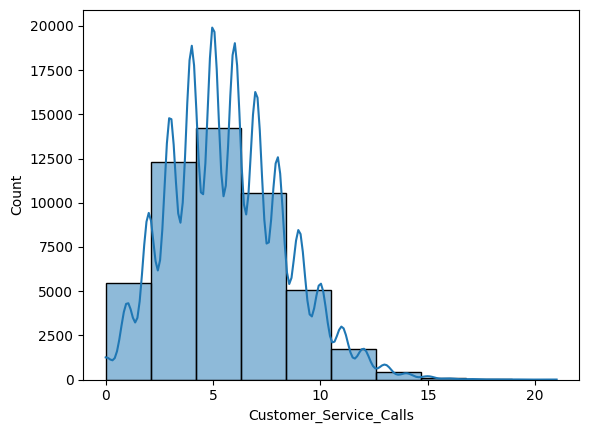

In [19]:
sns.histplot(df["Customer_Service_Calls"], bins=10, kde=True)

Right-skewed discrete ซึ่ง เหมือนกับ “จำนวนครั้งที่ลูกค้าติดต่อ support” มาก